# Extracción de conjunto completo

In [1]:
import os
import h5py
from PIL import Image

hdf5_path = "/kaggle/input/datasets/mrpeponee/cocahis/CoCaHis.hdf5"
output_dir = "/kaggle/working/cocahis"

os.makedirs(output_dir, exist_ok=True)

with h5py.File(hdf5_path, "r") as f:

    # Extract RGB images
    for dataset_name in ["raw", "sn1", "sn2"]:

        dataset = f[f"HE/{dataset_name}"]

        folder = os.path.join(output_dir, dataset_name)
        os.makedirs(folder, exist_ok=True)

        for i in range(dataset.shape[0]):
            img = Image.fromarray(dataset[i])
            img.save(os.path.join(folder, f"{i:03d}.png"))

    # Extract masks
    gt_names = [
        "GT1", "GT2", "GT3", "GT4",
        "GT5", "GT6", "GT7",
        "GT_majority_vote"
    ]

    for gt_name in gt_names:

        dataset = f[f"GT/{gt_name}"]

        folder = os.path.join(output_dir, gt_name)
        os.makedirs(folder, exist_ok=True)

        for i in range(dataset.shape[0]):
            mask = Image.fromarray(dataset[i])
            mask.save(os.path.join(folder, f"{i:03d}.png"))

print("Extraction complete.")

Extraction complete.


# Analisis de tejido canceroso en imágenes

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image

mask_dir = "/kaggle/working/cocahis/GT_majority_vote"

results = []

for fname in sorted(os.listdir(mask_dir)):

    if not fname.endswith(".png"):
        continue

    mask = np.array(Image.open(os.path.join(mask_dir, fname)))

    cancer_pixels = np.sum(mask == 1)
    non_cancer_pixels = np.sum(mask == 0)

    pct_cancer = 100 * cancer_pixels / mask.size

    results.append({
        "image": fname,
        "cancer_pixels": cancer_pixels,
        "non_cancer_pixels": non_cancer_pixels,
        "pct_cancer": pct_cancer
    })

df = pd.DataFrame(results)

print("Images containing cancer:",
      (df["cancer_pixels"] > 0).sum())

print("Images without cancer:",
      (df["cancer_pixels"] == 0).sum())

print("\nTop 20 most cancerous images:")
print(
    df.sort_values("pct_cancer", ascending=False)
      .head(20)
)

df.to_csv("cocahis_tumor_percentages.csv", index=False)

Images containing cancer: 82
Images without cancer: 0

Top 20 most cancerous images:
      image  cancer_pixels  non_cancer_pixels  pct_cancer
54  054.png        1133304             306052   78.736880
66  066.png        1068028             371328   74.201796
0   000.png         970400             468956   67.419040
56  056.png         967392             471964   67.210058
4   004.png         961882             477474   66.827248
39  039.png         961399             477957   66.793691
7   007.png         956171             483185   66.430473
2   002.png         920460             518896   63.949433
1   001.png         919542             519814   63.885654
47  047.png         894960             544396   62.177807
62  062.png         887490             551866   61.658825
55  055.png         886712             552644   61.604773
33  033.png         849613             589743   59.027301
38  038.png         842986             596370   58.566887
64  064.png         822957             616399

# Descripción

In [3]:
print(df["pct_cancer"].describe())

count    82.000000
mean     32.751642
std      20.720154
min       1.994920
25%      16.213901
50%      27.398573
75%      52.284841
max      78.736880
Name: pct_cancer, dtype: float64


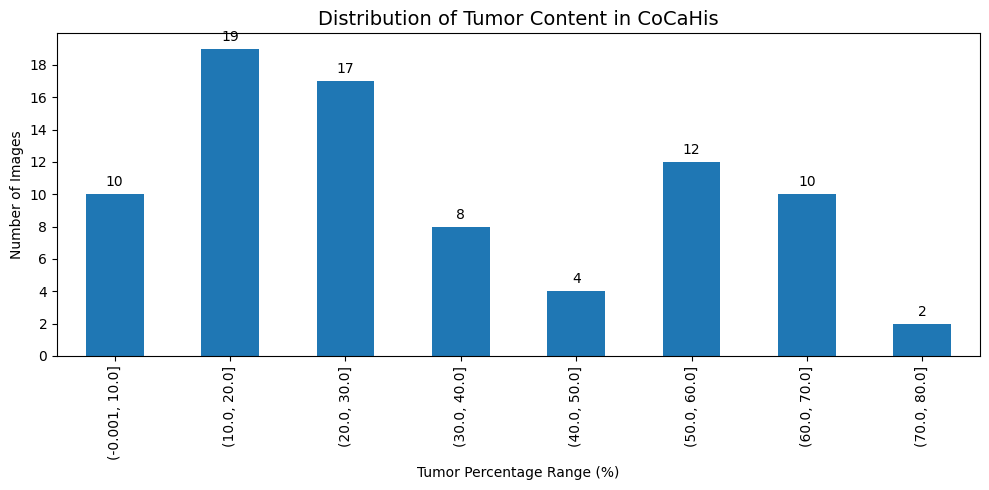


Images per tumor percentage range:

tumor_range
(-0.001, 10.0]    10
(10.0, 20.0]      19
(20.0, 30.0]      17
(30.0, 40.0]       8
(40.0, 50.0]       4
(50.0, 60.0]      12
(60.0, 70.0]      10
(70.0, 80.0]       2
Name: count, dtype: int64


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from PIL import Image

# =====================================================
# Calculate tumor percentage per image
# =====================================================

mask_dir = "/kaggle/working/cocahis/GT_majority_vote"

results = []

for fname in sorted(os.listdir(mask_dir)):

    if not fname.endswith(".png"):
        continue

    mask = np.array(
        Image.open(os.path.join(mask_dir, fname))
    )

    cancer_pixels = np.sum(mask == 1)

    results.append({
        "image": fname,
        "pct_cancer": 100 * cancer_pixels / mask.size
    })

df = pd.DataFrame(results)

# =====================================================
# Create tumor percentage ranges
# =====================================================

ranges = [0, 10, 20, 30, 40, 50, 60, 70, 80]

df["tumor_range"] = pd.cut(
    df["pct_cancer"],
    bins=ranges,
    include_lowest=True
)

counts = df["tumor_range"].value_counts().sort_index()

# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(10, 5))

counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Distribution of Tumor Content in CoCaHis",
    fontsize=14
)

ax.set_xlabel("Tumor Percentage Range (%)")
ax.set_ylabel("Number of Images")

# Force integer ticks on Y axis
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Show counts above each bar
for i, value in enumerate(counts.values):
    ax.text(
        i,
        value + 0.3,
        str(value),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# =====================================================
# Print table
# =====================================================

print("\nImages per tumor percentage range:\n")
print(counts)